Default case analysis

In [1]:
%run setup.py
mdates.set_epoch('2025-01-01')
from import_data import get_data


In [2]:
filenames = ['case1/case1.sqlite']

In [3]:
# list all unphysical commodities that should be ignored
ignore_commods = ['fluorine', 'oxygen', 'extra_fluorine', 'extra_oxygen', 'silica']

In [4]:
data = {}
for file in filenames:
    (name, file_data) = get_data(file, ignore_commods)
    
    print(name)
    
    data[name] = file_data

if len(data.keys()) == 1:
    data = data[list(data.keys())[0]]

case1


In [5]:
data.keys()

dict_keys(['db', 'ev', 'agents', 'facilities', 'transactions', 'ei', 'rx_events'])

In [6]:
data['transactions'].columns

Index(['SimId', 'ResourceId', 'ObjId', 'Type', 'TimeCreated', 'Quantity',
       'Units', 'QualId', 'PackageName', 'Parent1', 'Parent2', 'TransactionId',
       'SenderId', 'ReceiverId', 'Commodity', 'Time', 'SenderSpec',
       'SenderPrototype', 'ReceiverSpec', 'ReceiverPrototype',
       'SenderProtAgentId', 'ReceiverProtAgentId', 'Date',
       'CumQuantityReceived', 'CumQuantitySent', 'SSCumQuantityReceived',
       'SSCumQuantitySent'],
      dtype='object')

In [7]:
data['transactions']['Date'] = mdates.num2date(data['transactions']['Time'])

In [8]:
#data['agents']['Prototype'][0:50]

In [9]:
#data['agents']['Prototype'][50:87]

In [10]:
conv_fac = []

enr_fac = ['EnrichmentReceiver',
           'EnrichmentSeparation',
           'Enrichment',
           'EnrichmentRecipeRequester',
           'EnrichmentMixer',
           'EnrichmentShipper']

enr_tails_fac = [
    'EnrichmentTailsMixer',
    'EnrichmentTailsPackager',
    'EnrichmentTailsStorage']

ff_fac = [
    'FuelFabReceiver',
    'FuelFabSeparation',
    'FuelFabMixer',
    'FuelFabShipper',
    'HALEUFuelFabReceiver',
    'HALEUFuelFabSeparation',
    'HALEUFuelFabMixer',
    'HALEUFuelFabShipper']

rx_A = [
    'RxA1Storage',
    'RxA2Storage',
    'RxA3Storage',
    'RxA4Storage',
    'RxAShipper']

rx_B = [
    'RxB1Reactor',
    'RxB2Reactor',
    'RxB3FreshFuelVault',
    'RxB3Reactor',
    'RxB4FreshFuelVault',
    'RxB4Reactor',
    'RxBBlueSpentFuelPool',
    'RxBRedSpentFuelPool']

rx_C = [
    'RxC1FreshFuelVault',
    'RxC1Reactor',
    'RxC2FreshFuelVault',
    'RxC2Reactor',
    'RxC3FreshFuelVault',
    'RxC3Reactor',
    'RxC4FreshFuelVault',
    'RxC4Reactor',
    'RxCBlueSpentFuelPool',
    'RxCRedSpentFuelPool',
    'RxCShipper']

rx_D = [
    'RxD1FreshFuelVault',
    'RxD1Reactor',
    'RxD2FreshFuelVault',
    'RxD2Reactor',
    'RxD3FreshFuelVault',
    'RxD3Reactor',
    'RxD4FreshFuelVault',
    'RxD4Reactor',
    'RxDBlueSpentFuelPool',
    'RxDRedSpentFuelPool',
    'RxDShipper']
   

In [11]:
enr_fac[0]

'EnrichmentReceiver'

In [12]:
enr_rec = {}
for ag in enr_fac:
    enr_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

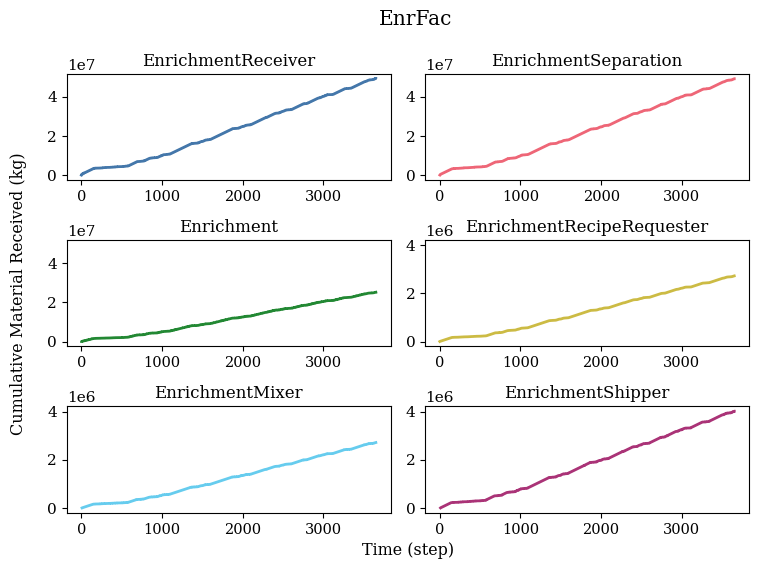

In [13]:
fig = plt.figure(figsize = (8, 6))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(321)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# ax0.set_xlim([0,50])
# ax0.set_xticks(np.arange(0, 50, 7))
# ax0.set_ylim([0,3e6])
# ax0.set_yticks(np.arange(0, 25, 5))

ax0.step(enr_rec[enr_fac[0]]['Time'],
         enr_rec[enr_fac[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(enr_fac[0])

###

ax1 = fig.add_subplot(322, sharex=ax0, sharey=ax0)
ax1.step(enr_rec[enr_fac[1]]['Time'],
         enr_rec[enr_fac[1]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(enr_fac[1])

###

ax2 = fig.add_subplot(323, sharex=ax0, sharey=ax0)
ax2.step(enr_rec[enr_fac[2]]['Time'],
         enr_rec[enr_fac[2]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(enr_fac[2])

###

ax3 = fig.add_subplot(324)#, sharex=ax0, sharey=ax0)
ax3.step(enr_rec[enr_fac[3]]['Time'],
         enr_rec[enr_fac[3]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(enr_fac[3])

###

ax4 = fig.add_subplot(325, sharex=ax3, sharey=ax3)
ax4.step(enr_rec[enr_fac[4]]['Time'],
         enr_rec[enr_fac[4]]['CumQuantityReceived'],
         color= palette[4])
ax4.set_title(enr_fac[4])

###

ax5 = fig.add_subplot(326, sharex=ax3, sharey=ax3)
ax5.step(enr_rec[enr_fac[5]]['Time'],
         enr_rec[enr_fac[5]]['CumQuantityReceived'],
         color= palette[5])
ax5.set_title(enr_fac[5])

fig.suptitle('EnrFac', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [14]:
ts=data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper'].groupby(by=['Time'])['Quantity'].sum().reset_index()
ts

,Time,Quantity
0,18,9108.000000
1,23,8905.948225
2,29,9108.000000
3,34,8905.948225
4,40,9108.000000
...,...,...
445,3626,8596.000000
446,3641,8596.000000
447,3643,9108.000000
448,3646,8596.000000


In [15]:
ffrec_dom=data['transactions'].loc[data['transactions']['ReceiverPrototype'] == 'FuelFabReceiver'].groupby(by=['Time', 'SenderPrototype'])['Quantity'].sum().reset_index()
ffrec_dom

,Time,SenderPrototype,Quantity
0,18,EnrichmentShipper,9108.000000
1,23,EnrichmentShipper,8905.948225
2,29,EnrichmentShipper,9108.000000
3,34,EnrichmentShipper,8905.948225
4,40,EnrichmentShipper,9108.000000
...,...,...,...
445,3626,EnrichmentShipper,8596.000000
446,3641,EnrichmentShipper,8596.000000
447,3643,EnrichmentShipper,9108.000000
448,3646,EnrichmentShipper,8596.000000


In [16]:
data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper'] ['Time']

393        18
394        18
395        18
392        18
472        23
         ... 
54182    3646
54231    3648
54232    3648
54233    3648
54230    3648
Name: Time, Length: 1800, dtype: int64

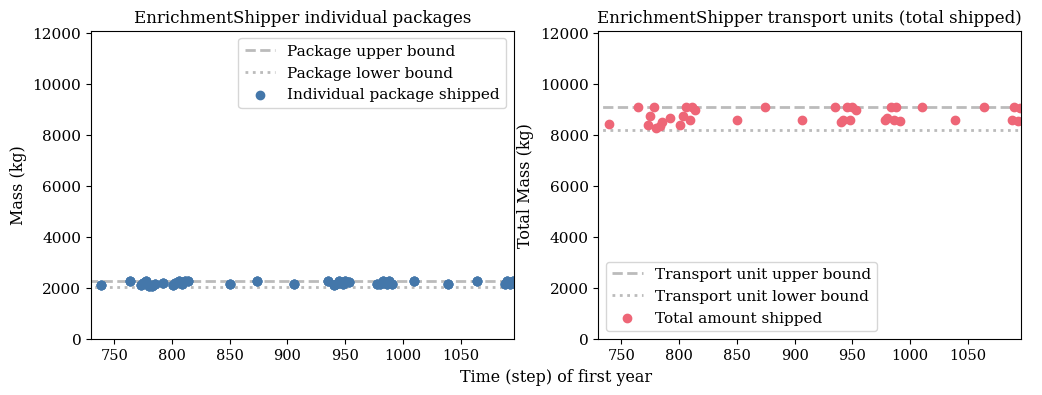

In [39]:
fig = plt.figure(figsize = (12, 4))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step) of first year')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

ax0 = fig.add_subplot(121)

ax0.hlines(y=2277,xmin=-5,xmax=3651, colors=palette[-2], linestyles='dashed', label='Package upper bound', zorder=0)
ax0.hlines(y=2049.30,xmin=-5,xmax=3651, colors=palette[-2], linestyles='dotted', label='Package lower bound', zorder=0)

# ax0.hlines(y=293.84,xmin=-5,xmax=3651, colors=palette[-2], linestyles='dashdot', label='Export demand limited', zorder=0)

end_startup = 730
ax0.set_xlim([end_startup,end_startup+366])
ax0.set_ylim([0,12100])
ax0.set_ylabel('Mass (kg)')

ax0.scatter(data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper'] ['Time'],
         data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper'] ['Quantity'],
         color= palette[0],
           label="Individual package shipped")
ax0.set_title(enr_fac[5] + " individual packages")

# ax0.xaxis.set_major_locator(mdates.MonthLocator())
# ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax0.legend()

ax1 = fig.add_subplot(122, sharex=ax0)

ax1.hlines(y=9108,xmin=-5,xmax=3651, colors=palette[-2], linestyles='dashed', label='Transport unit upper bound', zorder=0)
ax1.hlines(y=8197.2,xmin=-5,xmax=3651, colors=palette[-2], linestyles='dotted', label='Transport unit lower bound', zorder=0)

# ax1.set_xlim([00,365])
ax1.set_ylim([0,12100])
ax1.set_ylabel('Total Mass (kg)')

ax1.scatter(ts['Time'],
         ts['Quantity'],
         color= palette[1],
           label="Total amount shipped")
ax1.set_title(enr_fac[5] + " transport units (total shipped)")

# ax1.xaxis.set_major_locator(mdates.MonthLocator())
# ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax1.legend()


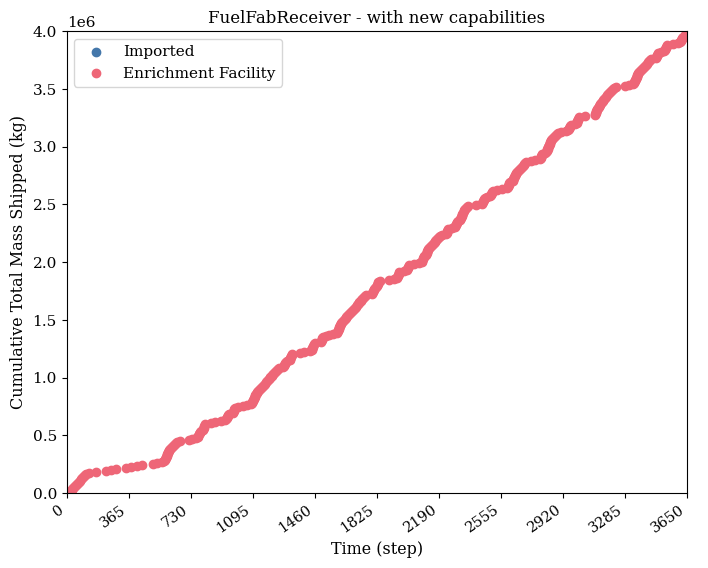

In [18]:
fig = plt.figure(figsize = (8, 6))
# fig = plt.figure(figsize = (12, 8))

ax = fig.add_subplot(111)

ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)


ax1 = fig.add_subplot(111)
ax1.set_xlim([00,1825])
ax1.set_ylim([0,4000000])
ax1.set_ylabel('Cumulative Total Mass Shipped (kg)')

ax1.scatter(ffrec_dom.loc[ffrec_dom['SenderPrototype'] == 'ForeignLEUF6Shipper']['Time'],
         ffrec_dom.loc[ffrec_dom['SenderPrototype'] == 'ForeignLEUF6Shipper']['Quantity'].cumsum(),
         color= palette[0],
           label="Imported")
ax1.scatter(ffrec_dom.loc[ffrec_dom['SenderPrototype'] == 'EnrichmentShipper']['Time'],
         ffrec_dom.loc[ffrec_dom['SenderPrototype'] == 'EnrichmentShipper']['Quantity'].cumsum(),
         color= palette[1],
           label="Enrichment Facility")
# ax1.set_title(enr_fac[5])

ax1.set_xlabel('Time (step)')
ax1.set_xticks(np.arange(0, 3655, 365))
for label in ax1.get_xticklabels(which='major'):
    label.set(rotation=35, horizontalalignment='right')

ax1.set_title('FuelFabReceiver - with new capabilities')
ax1.legend()

In [19]:
data['transactions'].loc[(data['transactions']['SenderPrototype'] == 'EnrichmentShipper') & (data['transactions']['Time'] < 25)]

,SimId,ResourceId,ObjId,Type,TimeCreated,Quantity,Units,QualId,PackageName,Parent1,...,SenderPrototype,ReceiverSpec,ReceiverPrototype,SenderProtAgentId,ReceiverProtAgentId,Date,CumQuantityReceived,CumQuantitySent,SSCumQuantityReceived,SSCumQuantitySent
393,81c85126-917c-413a-af85-5c09bc358581,4769,3709,Material,18,2277.000000,kg,1168,Type30B_UF6_cylinder,4768,...,EnrichmentShipper,:cycamore:Storage,FuelFabReceiver,EnrichmentShipper127,FuelFabReceiver129,2025-01-19 00:00:00+00:00,2277.000000,2277.000000,NaN,NaN
394,81c85126-917c-413a-af85-5c09bc358581,4775,3711,Material,18,2277.000000,kg,1170,Type30B_UF6_cylinder,4774,...,EnrichmentShipper,:cycamore:Storage,FuelFabReceiver,EnrichmentShipper127,FuelFabReceiver129,2025-01-19 00:00:00+00:00,4554.000000,4554.000000,NaN,NaN
395,81c85126-917c-413a-af85-5c09bc358581,4780,3713,Material,18,2277.000000,kg,1171,Type30B_UF6_cylinder,4779,...,EnrichmentShipper,:cycamore:Storage,FuelFabReceiver,EnrichmentShipper127,FuelFabReceiver129,2025-01-19 00:00:00+00:00,6831.000000,6831.000000,NaN,NaN
392,81c85126-917c-413a-af85-5c09bc358581,4764,3707,Material,18,2277.000000,kg,1167,Type30B_UF6_cylinder,4763,...,EnrichmentShipper,:cycamore:Storage,FuelFabReceiver,EnrichmentShipper127,FuelFabReceiver129,2025-01-19 00:00:00+00:00,9108.000000,9108.000000,NaN,NaN
472,81c85126-917c-413a-af85-5c09bc358581,5483,4142,Material,23,2226.487056,kg,1867,Type30B_UF6_cylinder,5482,...,EnrichmentShipper,:cycamore:Storage,FuelFabReceiver,EnrichmentShipper127,FuelFabReceiver129,2025-01-24 00:00:00+00:00,11334.487056,11334.487056,NaN,NaN
471,81c85126-917c-413a-af85-5c09bc358581,5481,4141,Material,23,2226.487056,kg,1866,Type30B_UF6_cylinder,5480,...,EnrichmentShipper,:cycamore:Storage,FuelFabReceiver,EnrichmentShipper127,FuelFabReceiver129,2025-01-24 00:00:00+00:00,13560.974112,13560.974112,NaN,NaN
470,81c85126-917c-413a-af85-5c09bc358581,5476,4139,Material,23,2226.487056,kg,1865,Type30B_UF6_cylinder,5475,...,EnrichmentShipper,:cycamore:Storage,FuelFabReceiver,EnrichmentShipper127,FuelFabReceiver129,2025-01-24 00:00:00+00:00,15787.461169,15787.461169,NaN,NaN
469,81c85126-917c-413a-af85-5c09bc358581,5470,4137,Material,23,2226.487056,kg,1863,Type30B_UF6_cylinder,5469,...,EnrichmentShipper,:cycamore:Storage,FuelFabReceiver,EnrichmentShipper127,FuelFabReceiver129,2025-01-24 00:00:00+00:00,18013.948225,18013.948225,NaN,NaN


In [20]:
len(ff_fac)

8

In [21]:
ff_rec = {}
for ag in ff_fac:
    ff_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

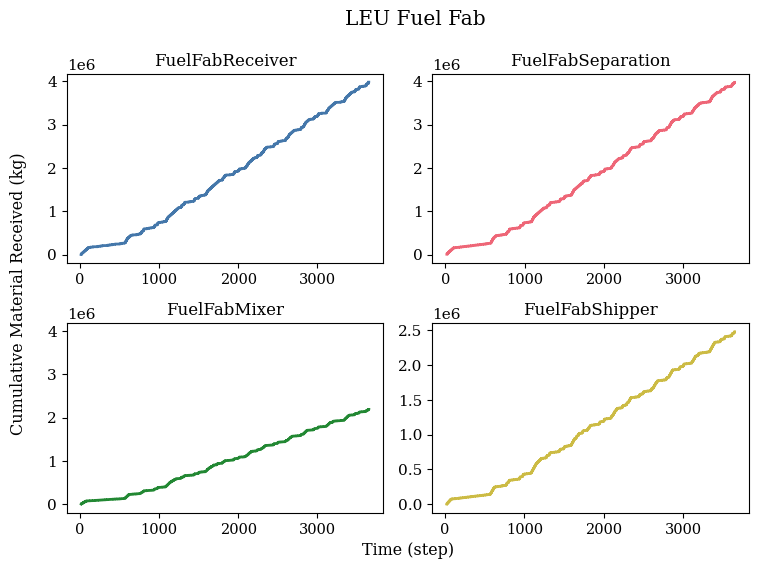

In [22]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)

###

ax0 = fig.add_subplot(221)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# plt.xlim(-0.5,16)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))

ax0.step(ff_rec[ff_fac[0]]['Time'],
         ff_rec[ff_fac[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(ff_fac[0])

###

ax1 = fig.add_subplot(222, sharex=ax0, sharey=ax0)
ax1.step(ff_rec[ff_fac[1]]['Time'],
         ff_rec[ff_fac[1]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(ff_fac[1])

###

ax2 = fig.add_subplot(223, sharex=ax0, sharey=ax0)
ax2.step(ff_rec[ff_fac[2]]['Time'],
         ff_rec[ff_fac[2]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(ff_fac[2])

###

ax3 = fig.add_subplot(224)#, sharex=ax0, sharey=ax0)
ax3.step(ff_rec[ff_fac[3]]['Time'],
         ff_rec[ff_fac[3]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(ff_fac[3])

###


fig.suptitle('LEU Fuel Fab', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


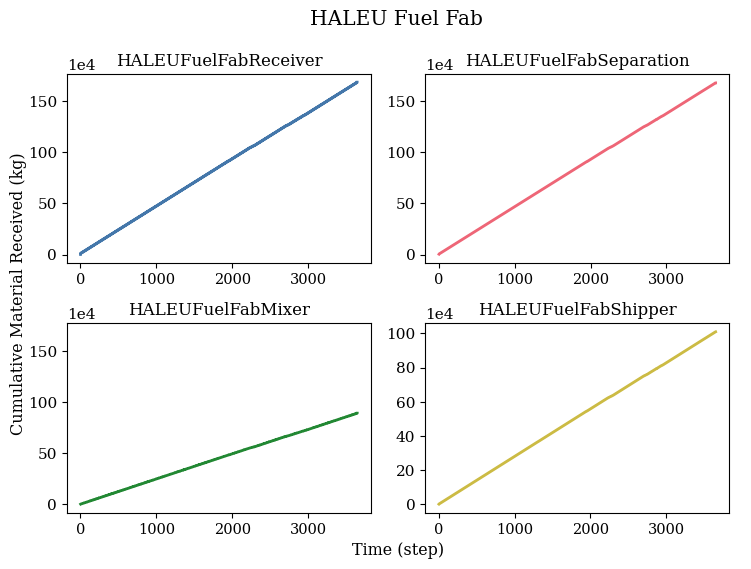

In [23]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(221)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# plt.xlim(-0.5,16)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(4,4))

ax0.step(ff_rec[ff_fac[4]]['Time'],
         ff_rec[ff_fac[4]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(ff_fac[4])

###

ax1 = fig.add_subplot(222, sharex=ax0, sharey=ax0)
ax1.step(ff_rec[ff_fac[5]]['Time'],
         ff_rec[ff_fac[5]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(ff_fac[5])

###

ax2 = fig.add_subplot(223, sharex=ax0, sharey=ax0)
ax2.step(ff_rec[ff_fac[6]]['Time'],
         ff_rec[ff_fac[6]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(ff_fac[6])

###

ax3 = fig.add_subplot(224)#, sharex=ax0, sharey=ax0)
ax3.step(ff_rec[ff_fac[7]]['Time'],
         ff_rec[ff_fac[7]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(ff_fac[7])
ax3.ticklabel_format(axis='y', style='sci', scilimits=(4,4))

###

fig.suptitle('HALEU Fuel Fab', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [24]:
x=data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper']
np.sort(x['Quantity'].unique())

array([2049.36339016, 2051.31098596, 2051.70946659, 2051.74773564,
       2052.48967867, 2054.18985551, 2056.03736543, 2056.83640205,
       2061.26236397, 2063.02562136, 2064.0394081 , 2065.41113658,
       2065.41113658, 2068.24480572, 2071.41573549, 2071.94762005,
       2073.01486383, 2074.54036883, 2080.63014977, 2080.63014977,
       2085.11540698, 2085.45479657, 2086.24881933, 2086.51598647,
       2086.98921241, 2090.00079854, 2090.82636288, 2091.52107218,
       2094.95520096, 2096.1020267 , 2098.55359208, 2101.95199253,
       2103.7702239 , 2105.37837712, 2106.77332261, 2106.88949598,
       2107.47731278, 2108.21550218, 2108.64400282, 2108.76387751,
       2108.76387751, 2109.17371993, 2109.56801908, 2110.066234  ,
       2112.46551895, 2113.61167239, 2121.07975399, 2122.13323193,
       2122.74304368, 2122.9721108 , 2123.68015527, 2126.00160758,
       2126.66614575, 2127.05241491, 2127.40200805, 2129.2904897 ,
       2130.84559611, 2131.47608731, 2132.01504936, 2135.47538

(array([ 60.,  44.,  68.,  72., 360.,  80.,  28., 272.,  44., 772.]),
 array([2049.36339016, 2072.12705114, 2094.89071212, 2117.65437311,
        2140.41803409, 2163.18169508, 2185.94535606, 2208.70901705,
        2231.47267803, 2254.23633902, 2277.        ]),
 <BarContainer object of 10 artists>)

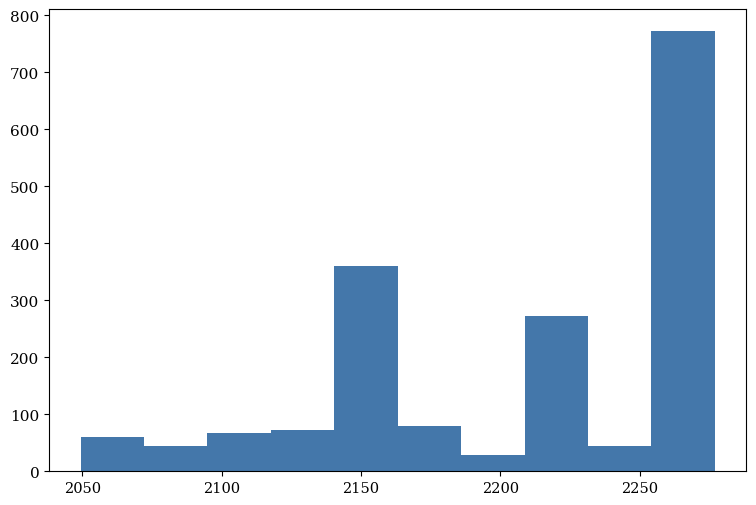

In [25]:
#x.loc[(x['Time'] < 630) & (x['Time'] > 570)]['Quantity'].unique()
plt.hist(x['Quantity'],10)

Text(0.5, 1.0, 'EnrichmentShipper')

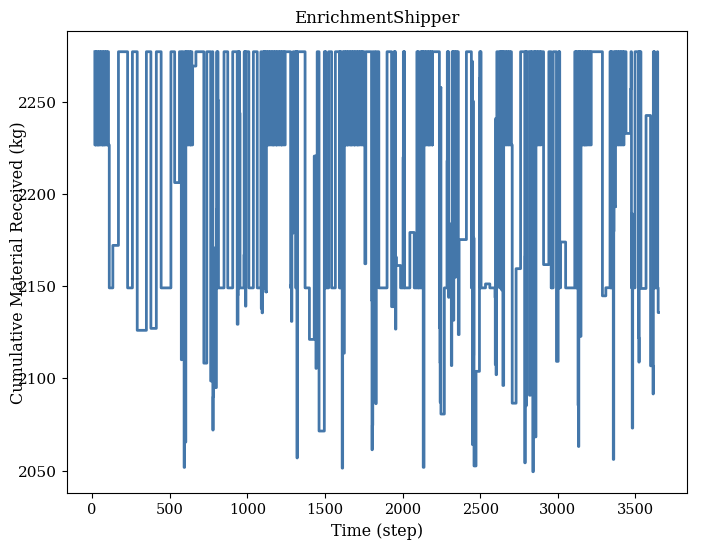

In [26]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(111)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# ax0.axis(xmin=570,
#          xmax=630)
# ax0.axis(ymin=0,
#          ymax=1000)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
#ax0.ticklabel_format(axis='y', style='sci')#, scilimits=(-4,4))

ax0.step(data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper']['Time'],
         data['transactions'].loc[data['transactions']['SenderPrototype'] == 'EnrichmentShipper']['Quantity'],
         color= palette[0])
ax0.set_title('EnrichmentShipper')

In [27]:
len(rx_A)

5

In [28]:
rxA_rec = {}
for ag in rx_A:
    rxA_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

rxB_rec = {}
for ag in rx_B:
    rxB_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

rxC_rec = {}
for ag in rx_C:
    rxC_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

rxD_rec = {}
for ag in rx_D:
    rxD_rec[ag] = data['transactions'].loc[data['transactions']['ReceiverPrototype'] == ag]

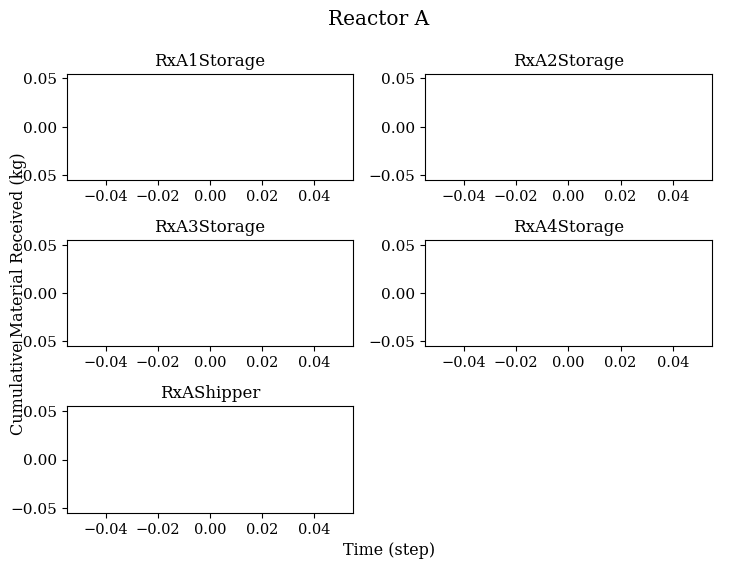

In [29]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(321)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# plt.xlim(-0.5,16)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(rxA_rec[rx_A[0]]['Time'],
         rxA_rec[rx_A[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_A[0])

###

ax1 = fig.add_subplot(322, sharex=ax0, sharey=ax0)
ax1.step(rxA_rec[rx_A[1]]['Time'],
         rxA_rec[rx_A[1]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(rx_A[1])

###

ax2 = fig.add_subplot(323, sharex=ax0, sharey=ax0)
ax2.step(rxA_rec[rx_A[2]]['Time'],
         rxA_rec[rx_A[2]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(rx_A[2])

###

ax3 = fig.add_subplot(324, sharex=ax0, sharey=ax0)
ax3.step(rxA_rec[rx_A[3]]['Time'],
         rxA_rec[rx_A[3]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(rx_A[3])

###

ax4 = fig.add_subplot(325, sharex=ax0, sharey=ax0)
ax4.step(rxA_rec[rx_A[4]]['Time'],
         rxA_rec[rx_A[4]]['CumQuantityReceived'],
         color= palette[3])
ax4.set_title(rx_A[4])

###

fig.suptitle('Reactor A', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [30]:
len(rx_B)

8

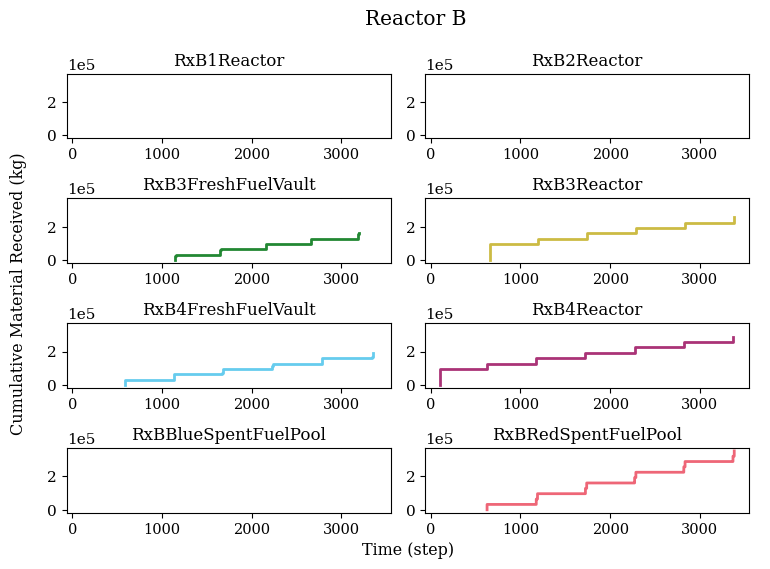

In [31]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(421)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
# plt.xlim(-0.5,1100)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(rxB_rec[rx_B[0]]['Time'],
         rxB_rec[rx_B[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_B[0])

###

ax1 = fig.add_subplot(422, sharex=ax0, sharey=ax0)
ax1.step(rxB_rec[rx_B[1]]['Time'],
         rxB_rec[rx_B[1]]['CumQuantityReceived'],
         color= palette[1])
ax1.set_title(rx_B[1])

###

ax2 = fig.add_subplot(423, sharex=ax0, sharey=ax0)
ax2.step(rxB_rec[rx_B[2]]['Time'],
         rxB_rec[rx_B[2]]['CumQuantityReceived'],
         color= palette[2])
ax2.set_title(rx_B[2])

###

ax3 = fig.add_subplot(424, sharex=ax0, sharey=ax0)
ax3.step(rxB_rec[rx_B[3]]['Time'],
         rxB_rec[rx_B[3]]['CumQuantityReceived'],
         color= palette[3])
ax3.set_title(rx_B[3])

###

ax4 = fig.add_subplot(425, sharex=ax0, sharey=ax0)
ax4.step(rxB_rec[rx_B[4]]['Time'],
         rxB_rec[rx_B[4]]['CumQuantityReceived'],
         color= palette[4])
ax4.set_title(rx_B[4])

###

ax5 = fig.add_subplot(426, sharex=ax0, sharey=ax0)
ax5.step(rxB_rec[rx_B[5]]['Time'],
         rxB_rec[rx_B[5]]['CumQuantityReceived'],
         color= palette[5])
ax5.set_title(rx_B[5])

###

ax6 = fig.add_subplot(427, sharex=ax0, sharey=ax0)
ax6.step(rxB_rec[rx_B[6]]['Time'],
         rxB_rec[rx_B[6]]['CumQuantityReceived'],
         color= palette[6])
ax6.set_title(rx_B[6])

###

ax7 = fig.add_subplot(428, sharex=ax0, sharey=ax0)
ax7.step(rxB_rec[rx_B[7]]['Time'],
         rxB_rec[rx_B[7]]['CumQuantityReceived'],
         color= palette[1])
ax7.set_title(rx_B[7])

###

fig.suptitle('Reactor B', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [32]:
len(rx_C)

11

In [33]:
print(rx_C)

['RxC1FreshFuelVault', 'RxC1Reactor', 'RxC2FreshFuelVault', 'RxC2Reactor', 'RxC3FreshFuelVault', 'RxC3Reactor', 'RxC4FreshFuelVault', 'RxC4Reactor', 'RxCBlueSpentFuelPool', 'RxCRedSpentFuelPool', 'RxCShipper']


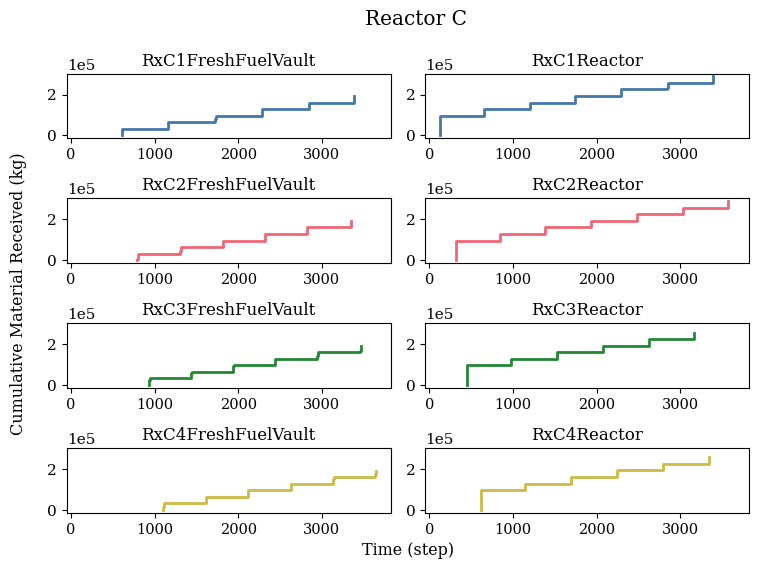

In [34]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(421)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
#plt.xlim(-0.5,1100)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(rxC_rec[rx_C[0]]['Time'],
         rxC_rec[rx_C[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_C[0])

###

ax1 = fig.add_subplot(422, sharex=ax0, sharey=ax0)
ax1.step(rxC_rec[rx_C[1]]['Time'],
         rxC_rec[rx_C[1]]['CumQuantityReceived'],
         color= palette[0])
ax1.set_title(rx_C[1])

###

ax2 = fig.add_subplot(423, sharex=ax0, sharey=ax0)
ax2.step(rxC_rec[rx_C[2]]['Time'],
         rxC_rec[rx_C[2]]['CumQuantityReceived'],
         color= palette[1])
ax2.set_title(rx_C[2])

###

ax3 = fig.add_subplot(424, sharex=ax0, sharey=ax0)
ax3.step(rxC_rec[rx_C[3]]['Time'],
         rxC_rec[rx_C[3]]['CumQuantityReceived'],
         color= palette[1])
ax3.set_title(rx_C[3])

###

ax4 = fig.add_subplot(425, sharex=ax0, sharey=ax0)
ax4.step(rxC_rec[rx_C[4]]['Time'],
         rxC_rec[rx_C[4]]['CumQuantityReceived'],
         color= palette[2])
ax4.set_title(rx_C[4])

###

ax5 = fig.add_subplot(426, sharex=ax0, sharey=ax0)
ax5.step(rxC_rec[rx_C[5]]['Time'],
         rxC_rec[rx_C[5]]['CumQuantityReceived'],
         color= palette[2])
ax5.set_title(rx_C[5])

###

ax6 = fig.add_subplot(427, sharex=ax0, sharey=ax0)
ax6.step(rxC_rec[rx_C[6]]['Time'],
         rxC_rec[rx_C[6]]['CumQuantityReceived'],
         color= palette[3])
ax6.set_title(rx_C[6])

###

ax7 = fig.add_subplot(428, sharex=ax0, sharey=ax0)
ax7.step(rxC_rec[rx_C[7]]['Time'],
         rxC_rec[rx_C[7]]['CumQuantityReceived'],
         color= palette[3])
ax7.set_title(rx_C[7])

###

fig.suptitle('Reactor C', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


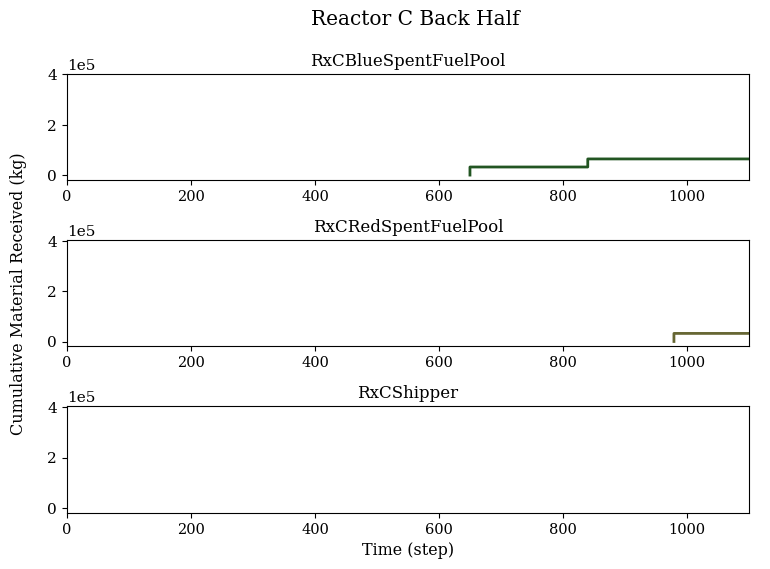

In [35]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(311)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
plt.xlim(-0.5,1100)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(rxC_rec[rx_C[8]]['Time'],
         rxC_rec[rx_C[8]]['CumQuantityReceived'],
         color= palette[8])
ax0.set_title(rx_C[8])

###

ax1 = fig.add_subplot(312, sharex=ax0, sharey=ax0)
ax1.step(rxC_rec[rx_C[9]]['Time'],
         rxC_rec[rx_C[9]]['CumQuantityReceived'],
         color= palette[9])
ax1.set_title(rx_C[9])

###

ax2 = fig.add_subplot(313, sharex=ax0, sharey=ax0)
ax2.step(rxC_rec[rx_C[10]]['Time'],
         rxC_rec[rx_C[10]]['CumQuantityReceived'],
         color= palette[10])
ax2.set_title(rx_C[10])

###

fig.suptitle('Reactor C Back Half', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


In [36]:
len(rx_D)

11

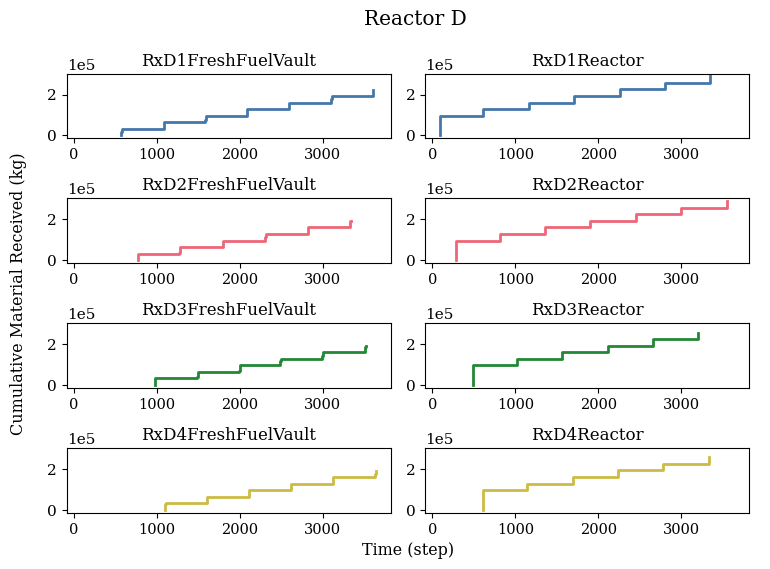

In [37]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(421)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
#plt.xlim(-0.5,1100)
# plt.ylim(0,20)
# ax0.set_xticks(np.arange(0, 16, 2))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(rxD_rec[rx_D[0]]['Time'],
         rxD_rec[rx_D[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_D[0])

###

ax1 = fig.add_subplot(422, sharex=ax0, sharey=ax0)
ax1.step(rxD_rec[rx_D[1]]['Time'],
         rxD_rec[rx_D[1]]['CumQuantityReceived'],
         color= palette[0])
ax1.set_title(rx_D[1])

###

ax2 = fig.add_subplot(423, sharex=ax0, sharey=ax0)
ax2.step(rxD_rec[rx_D[2]]['Time'],
         rxD_rec[rx_D[2]]['CumQuantityReceived'],
         color= palette[1])
ax2.set_title(rx_D[2])

###

ax3 = fig.add_subplot(424, sharex=ax0, sharey=ax0)
ax3.step(rxD_rec[rx_D[3]]['Time'],
         rxD_rec[rx_D[3]]['CumQuantityReceived'],
         color= palette[1])
ax3.set_title(rx_D[3])

###

ax4 = fig.add_subplot(425, sharex=ax0, sharey=ax0)
ax4.step(rxD_rec[rx_D[4]]['Time'],
         rxD_rec[rx_D[4]]['CumQuantityReceived'],
         color= palette[2])
ax4.set_title(rx_D[4])

###

ax5 = fig.add_subplot(426, sharex=ax0, sharey=ax0)
ax5.step(rxD_rec[rx_D[5]]['Time'],
         rxD_rec[rx_D[5]]['CumQuantityReceived'],
         color= palette[2])
ax5.set_title(rx_D[5])

###

ax6 = fig.add_subplot(427, sharex=ax0, sharey=ax0)
ax6.step(rxD_rec[rx_D[6]]['Time'],
         rxD_rec[rx_D[6]]['CumQuantityReceived'],
         color= palette[3])
ax6.set_title(rx_D[6])

###

ax7 = fig.add_subplot(428, sharex=ax0, sharey=ax0)
ax7.step(rxD_rec[rx_D[7]]['Time'],
         rxD_rec[rx_D[7]]['CumQuantityReceived'],
         color= palette[3])
ax7.set_title(rx_D[7])

###

fig.suptitle('Reactor D', x=0.55)
fig.tight_layout()

#plt.savefig('plots/cumulative-subplots', transparent=True)


Text(0.5, 1.0, 'RxD1FreshFuelVault')

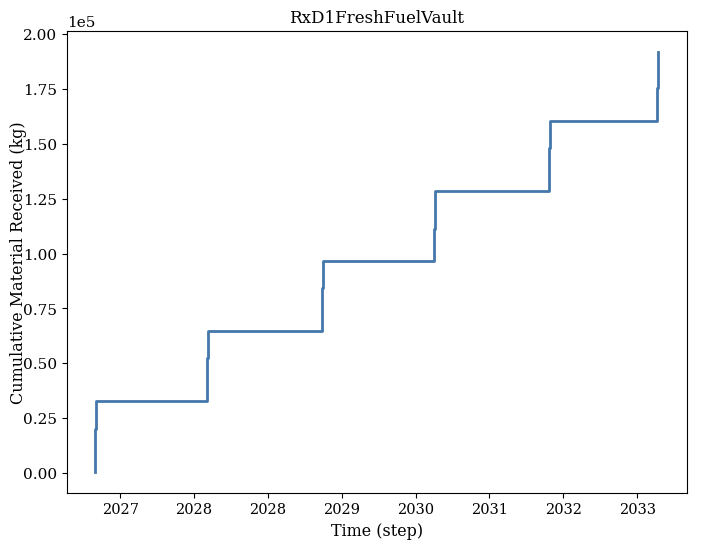

In [38]:
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111)
ax.set_xlabel('Time (step)')
ax.set_ylabel('Cumulative Material Received (kg)')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_color('none')
ax.spines['left'].set_color('none')
ax.spines['right'].set_color('none')
ax.tick_params(labelcolor='none', top= False, bottom= False, left= False, right= False)
###

ax0 = fig.add_subplot(111)
# ax.set_xlabel('Time')
# ax.set_ylabel('Quantity Received')
ax0.set_xticks(np.arange(0, 3650, 365))
# ax0.set_yticks(np.arange(0, 25, 5))
ax0.ticklabel_format(axis='y', style='sci', scilimits=(-4,4))

ax0.step(mdates.num2date(rxC_rec[rx_C[0]]['Time']),
         rxC_rec[rx_C[0]]['CumQuantityReceived'],
         color= palette[0])
ax0.set_title(rx_D[0])
